# Analisis Chatbot Mental Health AI

## Pertanyaan Bisnis

1. Emosi apa yang paling domninan pada dataset percakapan mental health ?
2. Apakah distribusi emosi pada dataset seimbang untuk kebutuhan pelatihan model chatbot?
3. Bagaimana karakteristik panjang teks input pengguna pada dataset chatbot mental health?
4. Apakah terdapat outlier pada panjang teks input pengguna yang dapat mempengaruhi kualitas model NLP?
5. Emosi apa yang memiliki rata-rata panjang teks paling tinggi pada percakapan pengguna?

## Import Semua Packages/Library yang Digunakan

In [43]:
import pandas as pd
import matplotlib.pyplot as plt


## Data Wrangling

### Gathering Data

In [44]:
chatbot_df = pd.read_csv("emotion-emotion_69k.csv")

**Insight:**
- Dataset memiliki lebih dari 64 ribu percakapan sehingga cukup besar dan representatif untuk kebutuhan analisis NLP serta pelatihan chatbot mental health


### Assessing Data

In [45]:
chatbot_df.head()

,Unnamed: 0,Situation,emotion,empathetic_dialogues,labels,Unnamed: 5,Unnamed: 6
0,0,I remember going to the fireworks with my best...,sentimental,Customer :I remember going to see the firework...,"Was this a friend you were in love with, or ju...",NaN,NaN
1,1,I remember going to the fireworks with my best...,sentimental,Customer :This was a best friend. I miss her.\...,Where has she gone?,NaN,NaN
2,2,I remember going to the fireworks with my best...,sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of...,NaN,NaN
3,3,I remember going to the fireworks with my best...,sentimental,Customer :Was this a friend you were in love w...,This was a best friend. I miss her.,NaN,NaN
4,4,I remember going to the fireworks with my best...,sentimental,Customer :Where has she gone?\nAgent :,We no longer talk.,NaN,NaN


In [46]:
chatbot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64636 entries, 0 to 64635
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            64636 non-null  int64 
 1   Situation             64636 non-null  object
 2   emotion               64632 non-null  object
 3   empathetic_dialogues  64636 non-null  object
 4   labels                64636 non-null  object
 5   Unnamed: 5            113 non-null    object
 6   Unnamed: 6            5 non-null      object
dtypes: int64(1), object(6)
memory usage: 3.5+ MB


In [47]:
chatbot_df.isnull().sum()

,0
Unnamed: 0,0
Situation,0
emotion,4
empathetic_dialogues,0
labels,0
Unnamed: 5,64523
Unnamed: 6,64631


In [48]:
chatbot_df.duplicated().sum()

np.int64(0)

In [49]:
chatbot_df.describe()

,Unnamed: 0
count,64636.000000
mean,32317.500000
std,18658.950337
min,0.000000
25%,16158.750000
50%,32317.500000
75%,48476.250000
max,64635.000000


In [50]:
chatbot_df.nunique()

,0
Unnamed: 0,64636
Situation,19205
emotion,43
empathetic_dialogues,63345
labels,63225
Unnamed: 5,92
Unnamed: 6,5


In [51]:
chatbot_df["emotion"].value_counts()

,count
emotion,
surprised,3295
excited,2465
angry,2296
proud,2247
annoyed,2213
sad,2213
lonely,2106
afraid,2094
grateful,2091


In [52]:
chatbot_df["emotion"].unique()

array(['sentimental', 'afraid', 'proud', 'faithful', 'terrified',
       'joyful', 'angry', 'sad', 'jealous', 'grateful', 'prepared',
       'embarrassed', 'excited', 'annoyed', 'lonely', 'ashamed', 'guilty',
       'surprised', 'nostalgic', 'confident', 'furious', 'disappointed',
       'caring', 'trusting', 'disgusted', 'anticipating', 'anxious',
       'hopeful', 'content', 'impressed', 'apprehensive', 'devastated',
       ' I really killed it!', ' we were in a different country',
       't even like scary things',
       't believe I like the show Power so much. I was never really into shows like that',
       nan, ' time to jump on the motorcycle and go cruising!',
       " a boy.  I hear all these different labor stories that aren't exactly reassuring!  ",
       't believe my daughter taught herself how to play the ukelele. I was amazed',
       't think I wold like super heroes',
       "m so mad with my brother. He stole from me and didn't think I would notice. ",
       " but

**Steps to Take:**
- Menghapus kolom yang tidak relevan
- Menangani Missing Value pada kolom emotion
- Membersihkan label emotion yang tidak valid
- Mengekstrak input pengguna dari kolom empathetic_dialogues
- Mmebuat kolom respon untuk chatbot
- Menghapus data kosong setelah transformasi


**Insight:**
- Dataset memiliki 64.636 baris dan 7 kolom pada kondisi awal, sehingga jumlah data cukup untuk kebutuhan analisis NLP dan pengembangan untuk chatbot
- Terdapat kolom yang tidak relevan, yaitu Unnamed: 0, Unnamed: 5, dan Unnamed: 6. Kolom Unnamed: 0 hanya berisi indeks, sedangkan Unnamed: 5 dan Unnamed: 6 memiliki missing value yang sangat besar sehingga perlu dihapus.
- Kolom emotion memiliki 4 missing value, sehingga perlu ditangani agar tidak mengganggu analisis distribusi emosi dan proses modeling.
Tidak ditemukan data duplikat pada dataset
- Kolom Situation memiliki 19.205 nilai unik, menunjukkan bahwa konteks percakapan cukup beragam/bervariasi.
- Kolom empathetic_dialogues memiliki 63.345 nilai unik dan kolom labels memiliki 63.225 nilai unik, sehingga dataset memiliki variasi percakapan dan respon yang sangat tinggi. Ini baik untuk pengembangan chatbot karena respon tidak monoton.
- Kolom emotion awalnya memiliki 43 nilai unik, tetapi hasil pengecekan unique() menunjukkan bahwa beberapa nilai bukan label emosi, melainkan teks percakapan yang masuk ke kolom tersebut. Ini menandakan adanya data tidak valid yang perlu dibersihkan.
- Kolom empathetic_dialogues masih berupa format mentah seperti Customer : ... Agent :, sehingga perlu ditransformasi menjadi kolom input_text agar sesuai dengan kebutuhan model chatbot.

### Cleaning Data

In [53]:
chatbot_df = chatbot_df.drop(columns=["Unnamed: 0","Unnamed: 5","Unnamed: 6"])

In [54]:
chatbot_df.dropna(inplace=True)

In [55]:
def extract_input(text):
    if pd.isna(text):
        return ""

    text = str(text)

    if "Customer :" in text:
        text = text.split("Customer :")[1]

    if "Agent :" in text:
        text = text.split("Agent :")[0]

    return text.strip()

In [56]:
chatbot_df["input_text"] = chatbot_df["empathetic_dialogues"].apply(extract_input)

In [57]:
valid_emotions = [
    'surprised','excited','annoyed','proud','angry','sad',
    'grateful','lonely','impressed','afraid','disgusted',
    'confident','terrified','hopeful','anxious','disappointed',
    'joyful','prepared','guilty','furious','nostalgic','jealous',
    'anticipating','embarrassed','content','devastated','sentimental',
    'caring','trusting','ashamed','apprehensive'
]

In [58]:
chatbot_df = chatbot_df[chatbot_df["emotion"].isin(valid_emotions)]

In [59]:
chatbot_df["input_text"] = chatbot_df["empathetic_dialogues"].apply(extract_input)
chatbot_df["response_text"] = chatbot_df["labels"]

In [60]:
chatbot_df = chatbot_df[
    (chatbot_df["input_text"] != "") &
    (chatbot_df["response_text"] != "")
]

In [61]:
final_df = chatbot_df[["input_text","response_text","emotion"]]

In [62]:
final_df = final_df.rename(columns={
    "emotion":"intent"
})

**Insight:**
- Proses cleaning diawali dengan menghapus kolom Unnamed: 0, Unnamed: 5, dan Unnamed: 6 karena kolom tersebut tidak memiliki kontribusi terhadap analisis maupun pengembangan model chatbot. Selain itu, dua kolom terakhir memiliki jumlah missing value yang sangat tinggi sehingga tidak layak dipertahankan.
- Dilakukan proses dropna() untuk menghapus data yang memiliki nilai kosong agar kualitas dataset lebih konsisten dan tidak menimbulkan error pada proses transformasi maupun modeling NLP.
- Dataset awal masih memiliki format percakapan mentah pada kolom empathetic_dialogues, sehingga dilakukan proses transformasi menggunakan fungsi extract_input() untuk mengekstrak bagian percakapan pengguna (Customer) dan memisahkannya dari bagian Agent.
- Hasil transformasi menghasilkan kolom baru bernama input_text yang berisi input pengguna secara lebih bersih dan terstruktur. Kolom ini akan digunakan sebagai fitur utama dalam analisis NLP dan pelatihan chatbot.
- Kolom labels kemudian digunakan sebagai response_text, yaitu respon chatbot terhadap input pengguna. Dengan demikian dataset berhasil diubah menjadi format percakapan standar:
input_text -> response_text
- Dilakukan filtering menggunakan valid_emotions agar hanya kategori emosi yang relevan dan valid yang dipertahankan.
- Setelah proses cleaning dan filtering dilakukan, dataset kemudian dibersihkan kembali dari data kosong pada kolom input_text dan response_text.
- Dataset akhir kemudian dipilih hanya menggunakan kolom:
input_text ; response_text ; emotion

## Feature Engineering

In [63]:
final_df["text_length"] = final_df["input_text"].apply(len)
final_df["response_length"] = final_df["response_text"].apply(len)

In [64]:
final_df[["text_length","response_length"]].describe()

,text_length,response_length
count,63308.000000,63308.000000
mean,67.815600,62.525747
std,43.332293,41.655745
min,1.000000,1.000000
25%,39.000000,34.000000
50%,58.000000,53.000000
75%,86.000000,80.000000
max,561.000000,561.000000


**Insight:**
- Pada tahap feature engineering dilakukan penambahan fitur baru berupa:
text_length ; response_lenght, yang digunakan untuk menghitung panjang teks pada input pengguna dan respon chatbot.


## Exploratory Data Analysis (EDA)

In [65]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63308 entries, 0 to 64635
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   input_text       63308 non-null  object
 1   response_text    63308 non-null  object
 2   intent           63308 non-null  object
 3   text_length      63308 non-null  int64 
 4   response_length  63308 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 2.9+ MB


In [66]:
final_df.shape

(63308, 5)

In [67]:
final_df.columns

Index(['input_text', 'response_text', 'intent', 'text_length',
       'response_length'],
      dtype='object')

In [68]:
final_df.describe(include="object")

,input_text,response_text,intent
count,63308,63308,63308
unique,62026,61935,31
top,What happened?,What happened?,surprised
freq,56,57,3295


In [69]:
final_df.isnull().sum()

,0
input_text,0
response_text,0
intent,0
text_length,0
response_length,0


In [70]:
final_df["input_text"].nunique()

62026

In [71]:
final_df["intent"].value_counts()

,count
intent,
surprised,3295
excited,2465
angry,2296
proud,2247
annoyed,2213
sad,2213
lonely,2106
afraid,2094
grateful,2091


In [72]:
Q1 = final_df["text_length"].quantile(0.25)
Q3 = final_df["text_length"].quantile(0.75)

IQR = Q3 - Q1


lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


outliers = final_df[
    (final_df["text_length"] < lower_bound) |
    (final_df["text_length"] > upper_bound)
]

print("Jumlah Outlier:", len(outliers))

outliers[["input_text", "text_length"]].head()

Jumlah Outlier: 2528


,input_text,text_length
0,I remember going to see the fireworks with my ...,194
48,I was at the beach and a hurricane changed tra...,168
64,It has a miss. Sometimes when you are driving ...,209
88,I was only married for 4 weeks when I learned ...,222
136,Have you ever had a pet that you had to put do...,172


**Insight:**
- Seluruh kolom pada dataset final memiliki tipe data object, yang sesuai untuk kebutuhan pemrosesan teks pada chatbot dan Natural Language Processing (NLP).
- Tidak ditemukan missing value pada dataset final. Hal ini menunjukkan proses cleaning dan transformation berhasil menghasilkan dataset yang lengkap dan konsisten.
- Kolom input_text memiliki 62.026 nilai unik, sedangkan response_text memiliki 61.935 nilai unik. Tingginya jumlah variasi data menunjukkan bahwa dataset memiliki percakapan yang sangat beragam sehingga cocok untuk pelatihan chatbot yang lebih natural dan tidak monoton.
- Kolom intent memiliki 31 kategori emosi valid, yang dapat digunakan sebagai label klasifikasi emosi pengguna pada chatbot mental health.
- " what happened?"  menjadi percakapan yang paling sering muncul baik pada input_text maupun response_text. Namun frekuensinya relatif kecil dibanding total dataset sehingga tidak menimbulkan dominasi berlebihan.
- Distribusi emotion relatif cukup baik meskipun masih terdapat sedikit ketidakseimbangan jumlah data antar kategori emosi. Namun kondisi ini masih tergolong aman untuk proses pelatihan model NLP dan chatbot.
- Hasil analisis menunjukkan terdapat 2.528 data outlier pada panjang teks input pengguna. Data tersebut memiliki panjang teks yang jauh lebih tinggi dibandingkan mayoritas percakapan lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

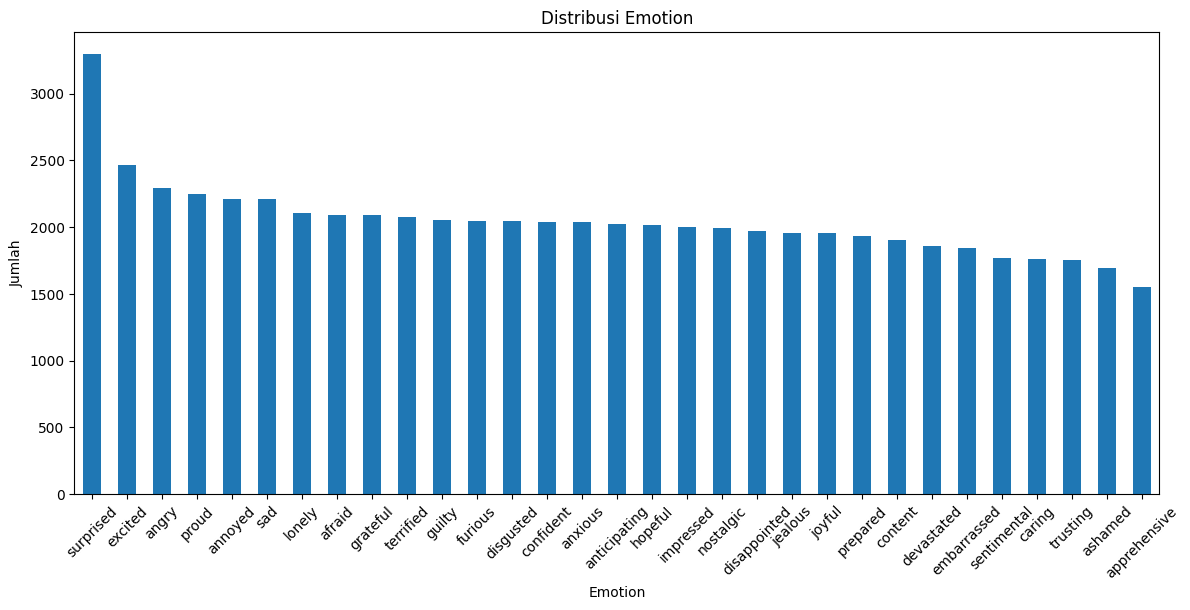

In [73]:
plt.figure(figsize=(14,6))
final_df["intent"].value_counts().plot(kind="bar")
plt.title("Distribusi Emotion")
plt.xlabel("Emotion")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

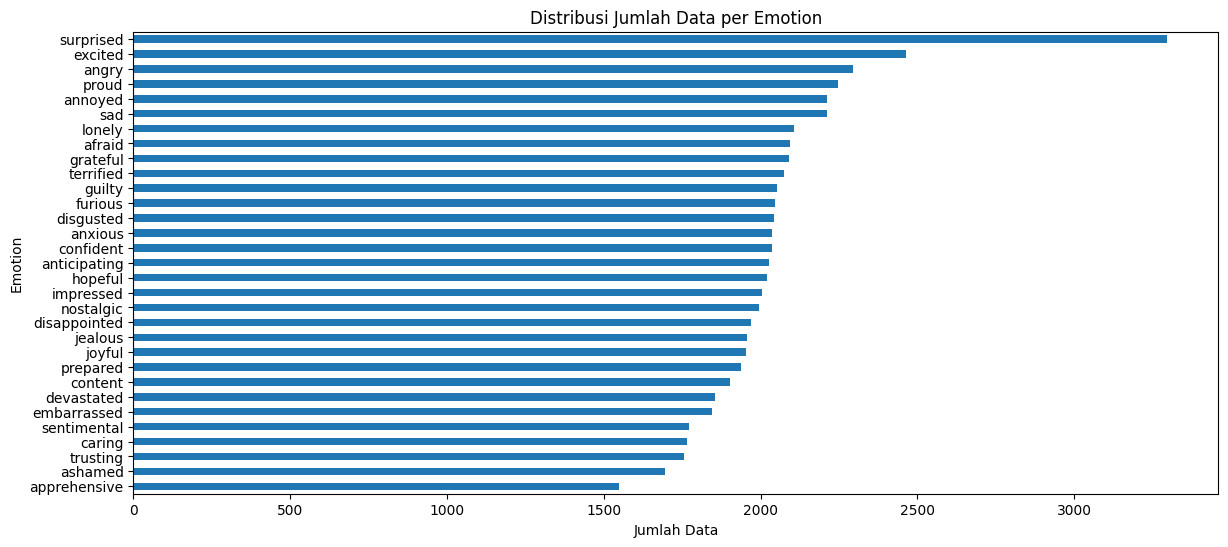

In [74]:
plt.figure(figsize=(14,6))

final_df["intent"].value_counts().sort_values().plot(kind="barh")

plt.title("Distribusi Jumlah Data per Emotion")
plt.xlabel("Jumlah Data")
plt.ylabel("Emotion")

plt.show()

### Pertanyaan 3:

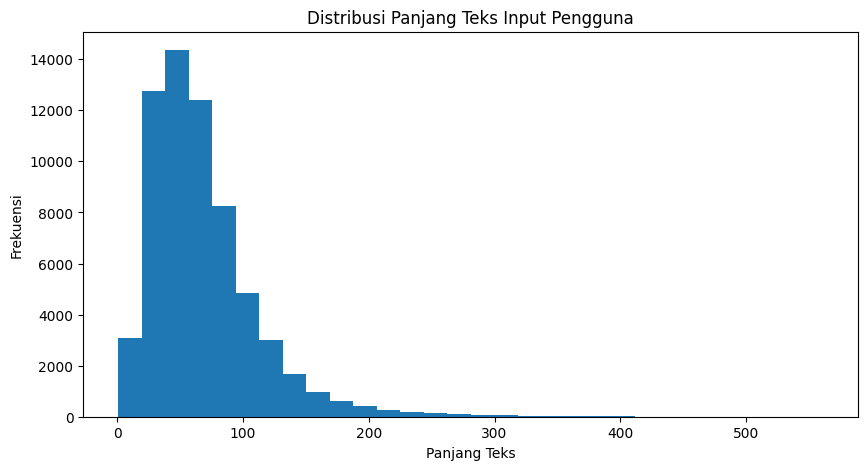

In [75]:
final_df["text_length"] = final_df["input_text"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(final_df["text_length"], bins=30)

plt.title("Distribusi Panjang Teks Input Pengguna")
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")

plt.show()

### Pertanyaan 4:

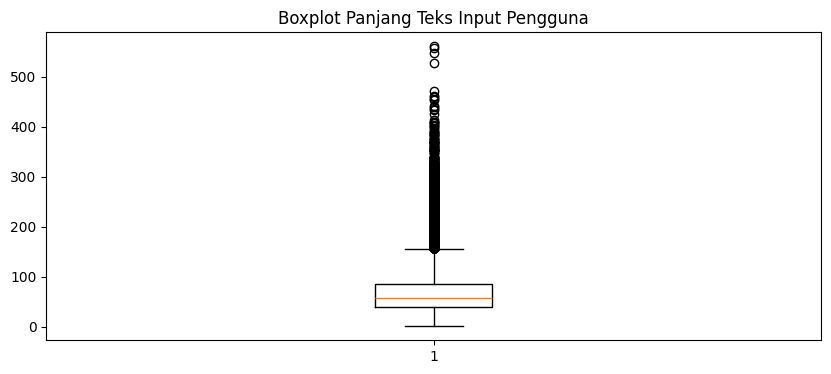

In [76]:
plt.figure(figsize=(10,4))

plt.boxplot(final_df["text_length"])

plt.title("Boxplot Panjang Teks Input Pengguna")

plt.show()

### Pertanyaan 5:

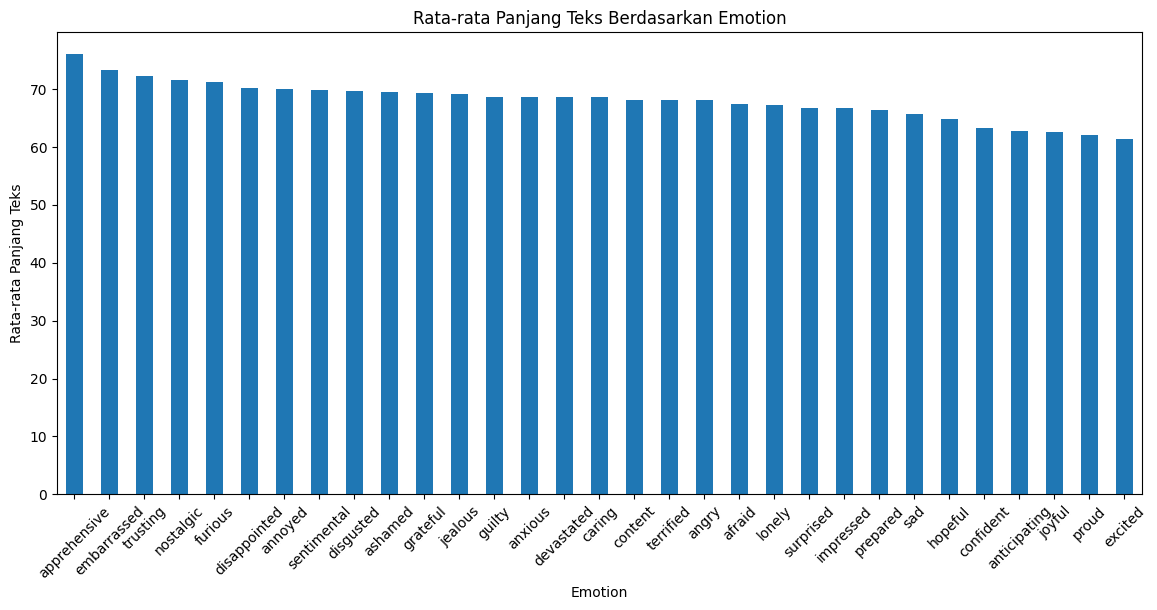

In [77]:
avg_text = final_df.groupby("intent")["text_length"].mean()

plt.figure(figsize=(14,6))

avg_text.sort_values(ascending=False).plot(kind="bar")

plt.title("Rata-rata Panjang Teks Berdasarkan Emotion")
plt.xlabel("Emotion")
plt.ylabel("Rata-rata Panjang Teks")

plt.xticks(rotation=45)

plt.show()

**Insight:**
- Pertanyaan 1 : Berdasarkan visualisasi distribusi emotion, kategori emosi surprised memiliki jumlah data paling tinggi dibandingkan kategori lainnya. Selain itu, kategori excited, angry, proud, dan sad juga memiliki jumlah data yang cukup besar.
- Pertanyaan 2 :Visualisasi menunjukkan bahwa distribusi jumlah data antar emotion belum sepenuhnya seimbang. Beberapa kategori seperti surprised dan excited memiliki jumlah data lebih tinggi dibanding kategori lainnya.Meskipun demikian, perbedaan distribusi antar kelas masih tergolong wajar dan dataset tetap memiliki variasi yang cukup baik untuk kebutuhan pelatihan model chatbot dan klasifikasi emosi.
- Pertanyaan 3 : Berdasarkan histogram distribusi panjang teks, sebagian besar input pengguna berada pada kategori teks pendek hingga menengah. Hal ini menunjukkan bahwa mayoritas percakapan pengguna berupa kalimat singkat yang umum ditemukan pada interaksi chatbot. Karakteristik ini sesuai untuk kebutuhan NLP dan chatbot karena model dapat lebih mudah mempelajari pola percakapan pengguna.
- Pertanyaan 4 : Outlier yang ditemukan tidak selalu menunjukkan kesalahan data (noise), melainkan dapat merepresentasikan percakapan emosional yang lebih kompleks dan informatif. Oleh karena itu, outlier pada dataset ini tidak langsung dihapus karena masih memiliki konteks yang relevan untuk pelatihan chatbot mental health dan pemodelan NLP.
- Pertanyaan 5 : Visualisasi menunjukkan bahwa beberapa kategori emosi memiliki rata-rata panjang teks lebih tinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa pengguna cenderung memberikan penjelasan lebih panjang ketika menyampaikan emosi tertentu. Panjang teks yang lebih tinggi dapat membantu chatbot memahami konteks emosional pengguna secara lebih mendalam.

In [78]:
final_df.head()

,input_text,response_text,intent,text_length,response_length
0,I remember going to see the fireworks with my ...,"Was this a friend you were in love with, or ju...",sentimental,194,63
1,This was a best friend. I miss her.,Where has she gone?,sentimental,35,19
2,We no longer talk.,Oh was this something that happened because of...,sentimental,18,59
3,"Was this a friend you were in love with, or ju...",This was a best friend. I miss her.,sentimental,63,35
4,Where has she gone?,We no longer talk.,sentimental,19,18


In [79]:
final_df.to_csv("clean_final_dataset.csv", index=False)